<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/miniProject3%20/%20MP3_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Q4***

# **Import libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# **Generate data**

In [ ]:
N = 300

u = np.random.uniform(-1, 1, N)


def g(u):
    return 0.6*np.sin(np.pi*u) + 0.3*np.sin(3*np.pi*u) + 0.1*np.sin(5*np.pi*u)

gu = g(u)

y = np.zeros(N)
for k in range(2, N):
    y[k] = 0.3*y[k-1] + 0.6*y[k-2] + g(u[k-1])

x_train = u
y_train = gu

# **Fuzzy membership functions**

In [ ]:
M = 11

c = np.linspace(-1, 1, M)
sigma = np.ones(M) * 0.2
y_rule = np.random.randn(M)

# **Define membership function**

In [ ]:
def gauss_mf(x, c, sigma):
    return np.exp(- ((x - c)**2) / (2 * sigma**2))

# **Define fuzzy output formula**

In [ ]:
def fuzzy_output(x, c, sigma, y_rule):
    M = len(c)
    weights = np.zeros(M)
    for i in range(M):
        weights[i] = gauss_mf(x, c[i], sigma[i])
    norm_weights = weights / np.sum(weights)
    return np.dot(norm_weights, y_rule)

# **Training by Gradient Descent**

In [ ]:
eta = 0.05
epochs = 400

for epoch in range(epochs):
    mse = 0
    for i in range(N):
        x_i = x_train[i]
        target = y_train[i]
        y_hat = fuzzy_output(x_i, c, sigma, y_rule)
        e = target - y_hat
        mse += e**2


        for m in range(M):
            w_m = gauss_mf(x_i, c[m], sigma[m])
            norm = sum(gauss_mf(x_i, c[j], sigma[j]) for j in range(M))
            y_rule[m] += eta * e * (w_m / norm)

    if epoch % 50 == 0:
        print(f"Epoch {epoch} - MSE: {mse / N:.4f}")

Epoch 0 - MSE: 0.3625
Epoch 50 - MSE: 0.0084
Epoch 100 - MSE: 0.0050
Epoch 150 - MSE: 0.0044
Epoch 200 - MSE: 0.0043
Epoch 250 - MSE: 0.0043
Epoch 300 - MSE: 0.0043
Epoch 350 - MSE: 0.0043


# **Evaluation and Visualization**

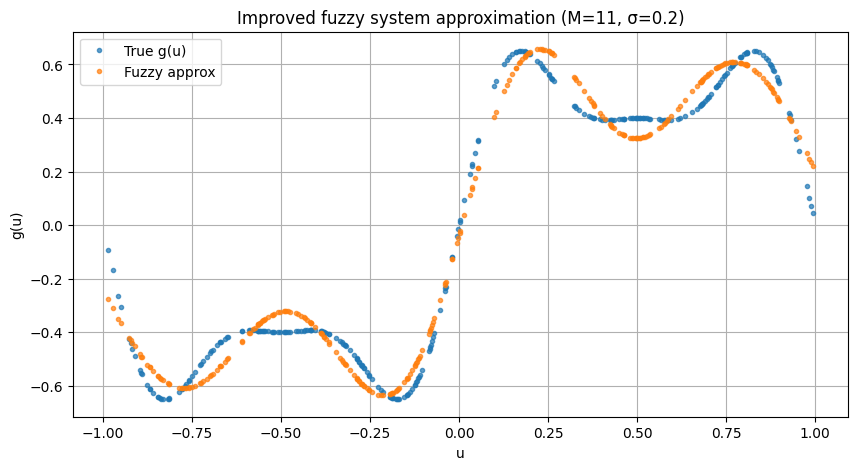

In [ ]:
gu_hat = np.zeros(N)
for i in range(N):
    gu_hat[i] = fuzzy_output(x_train[i], c, sigma, y_rule)

plt.figure(figsize=(10, 5))
plt.plot(x_train, y_train, '.', label='True g(u)', alpha=0.7)
plt.plot(x_train, gu_hat, '.', label='Fuzzy approx', alpha=0.7)
plt.xlabel('u')
plt.ylabel('g(u)')
plt.legend()
plt.grid()
plt.title('Improved fuzzy system approximation (M=11, σ=0.2)')
plt.show()

# ***Q5***

# **Part 1**

# **Import required libraries**

In [ ]:
!pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 35.3 MB/s eta 0:00:00


# **Define input universe and membership functions**

In [ ]:
x1 = np.linspace(-1, 1, 100)
x2 = np.linspace(-1, 1, 100)

x1_low = fuzz.trimf(x1, [-1.0, -1.0, 0.0])
x1_mid = fuzz.trimf(x1, [-1.0, 0.0, 1.0])
x1_high = fuzz.trimf(x1, [0.0, 1.0, 1.0])

x2_low = fuzz.trimf(x2, [-1.0, -1.0, 0.0])
x2_mid = fuzz.trimf(x2, [-1.0, 0.0, 1.0])
x2_high = fuzz.trimf(x2, [0.0, 1.0, 1.0])

# **Define rules and constant outputs**

In [ ]:
rule_outputs = np.ones((3, 3))

# **Evaluate fuzzy output on grid**

In [ ]:
X1, X2 = np.meshgrid(x1, x2)
output = np.zeros_like(X1)


x1_mfs = [x1_low, x1_mid, x1_high]
x2_mfs = [x2_low, x2_mid, x2_high]


for i in range(3):
    for j in range(3):
        mf1 = fuzz.interp_membership(x1, x1_mfs[i], X1)
        mf2 = fuzz.interp_membership(x2, x2_mfs[j], X2)
        weight = np.minimum(mf1, mf2)
        output += weight * rule_outputs[i, j]


output /= np.maximum(output.max(), 1e-5)

# **Plot result**

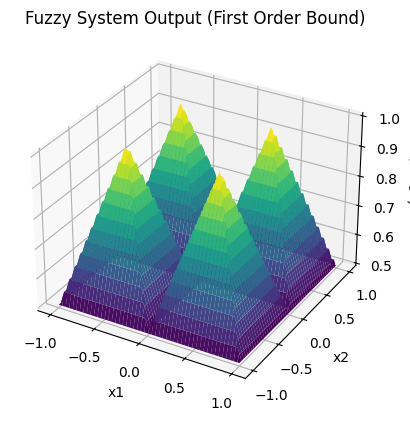

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, output, cmap='viridis')
ax.set_title('Fuzzy System Output (First Order Bound)')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('g(x1,x2)')
plt.show()

# **Part 2**

# **Membership functions (Second Order Bound)**

In [ ]:
centers = np.linspace(-1, 1, 5)
width = 0.5

def gauss_mf(x, c, w):
    return np.exp(-((x - c) ** 2) / (2 * w ** 2))

x1_mfs_2 = [gauss_mf(x1, c, width) for c in centers]
x2_mfs_2 = [gauss_mf(x2, c, width) for c in centers]

# **Evaluate system output**

In [ ]:
X1, X2 = np.meshgrid(x1, x2)
output_2 = np.zeros_like(X1)

for i in range(5):
    for j in range(5):
        mf1 = fuzz.interp_membership(x1, x1_mfs_2[i], X1)
        mf2 = fuzz.interp_membership(x2, x2_mfs_2[j], X2)
        weight = np.minimum(mf1, mf2)
        output_2 += weight * 1

output_2 /= np.maximum(output_2.max(), 1e-5)

# **Plot result**

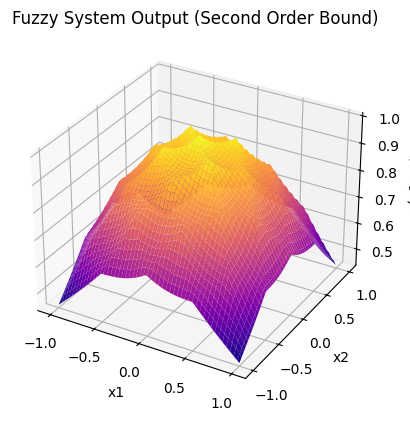

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, output_2, cmap='plasma')
ax.set_title('Fuzzy System Output (Second Order Bound)')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('g(x1,x2)')
plt.show()